# Customer 360 - Supervised Learning

### We will:

- remove `CustomerID` from model features
- separate targets before preprocessing
- use median imputation for numerical features
- use most-frequent imputation for categorical features
- standardize numerical features
- one-hot encode categorical features
- use handle_unknown="ignore"
- fit preprocessing only on training data through Pipeline

## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay ,classification_report ,roc_curve,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor,
    IsolationForest
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings("ignore") 

## Load Dataset

In [2]:
df = pd.read_csv('../data/processed/customer_360_features.csv')

df.shape
df.head(3)

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,...,Churn,TenureGroups,SupportCallsPerTenure,LatePaymentRate,UsagePerService,ChargePerService,EstimatedAnnualCharge,EstimatedTotalCharge,HighValueCustomer,SupportSatisfactionInteraction
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,...,Yes,2 Years,0.22,0.000000,63.58,116.10,6965.76,13351.04,1,0.0
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,...,No,<= Year,0.11,8.333333,359.30,434.36,5212.32,3909.24,0,1.0
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,...,No,2 Years,0.24,8.333333,58.97,130.45,4696.20,8218.35,0,0.0


## Data Preprocessing

### Define X and y (Classification & Regression)

In [3]:
drop_cols_class = ["CustomerID", "Churn", "Future12MRevenueEGP"]
drop_cols_reg = drop_cols_class + ['EstimatedAnnualCharge','EstimatedTotalCharge']

x_class = df.drop(columns= drop_cols_class)
x_reg = df.drop(columns= drop_cols_reg)

y_class = df["Churn"].map({"No": 0, "Yes": 1})
y_reg = df["Future12MRevenueEGP"]

### Identify numeric and categorical features

In [4]:
numeric_features = x_reg.select_dtypes(include=np.number).columns.tolist()
categorical_features = x_reg.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['Age', 'TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP', 'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore', 'SupportCallsPerTenure', 'LatePaymentRate', 'UsagePerService', 'ChargePerService', 'HighValueCustomer', 'SupportSatisfactionInteraction']

Categorical features: ['Region', 'ContractType', 'InternetType', 'PaperlessBilling', 'AutoPay', 'TenureGroups']


#### Removing Revenue-Derived Features

`EstimatedAnnualCharge` and `EstimatedTotalCharge` were excluded from the regression features.

Both variables are derived directly from existing financial and tenure variables and may provide redundant information when predicting `Future12MRevenueEGP`. Removing them also helps maintain a clear separation between predictor variables and revenue-related derived measures, reducing the risk of data leakage or overly optimistic model performance.

The original variables such as `MonthlyChargeEGP` and `TenureMonths` are retained because they represent information available at the time of prediction.

### Build reusable preprocessing pipeline

* missing-value imputation
* categorical encoding
* numeric scaling
* reusable sklearn pipelines

In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


### Train/test split (Classification)

In [6]:
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    x_class, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training set:", x_train_c.shape)
print("Test set:", x_test_c.shape)
print("Training churn rate:", y_train_c.mean().round(2))
print("Test churn rate:", y_test_c.mean().round(2))

Training set: (2400, 22)
Test set: (600, 22)
Training churn rate: 0.18
Test churn rate: 0.18


### Train/test split (Regression)

In [7]:
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x_reg, y_reg,
    test_size=0.2,
    random_state=42,
)

print("Training set:", x_train_r.shape)
print("Test set:", x_test_r.shape)
print("Training Future Revenue:", y_train_r.mean().round(2))
print("Test Future Revenue:", y_test_r.mean().round(2))

Training set: (2400, 20)
Test set: (600, 20)
Training Future Revenue: 5343.58
Test Future Revenue: 5431.46


## Part A: Churn Classification

### Classification models

In [8]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors= 5, weights='distance'),
    "Decision Tree": DecisionTreeClassifier(random_state=42,class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,class_weight='balanced'),
    "SVM": SVC(probability=True, random_state=42,class_weight='balanced'),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

classification_results = []
classification_pipelines = {}

for name, model in classification_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x_train_c, y_train_c)
    y_pred = pipe.predict(x_test_c)
    y_prob = pipe.predict_proba(x_test_c)[:, 1]

    classification_pipelines[name] = pipe

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, y_pred),
        "Precision": precision_score(y_test_c, y_pred, zero_division=0),
        "Recall": recall_score(y_test_c, y_pred, zero_division=0),
        "F1": f1_score(y_test_c, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_c, y_prob)
    })

classification_results_df = pd.DataFrame(classification_results).sort_values(
    "ROC-AUC", ascending=False).reset_index(drop=True)

classification_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.786667,0.373333,0.256881,0.304348,0.751462
1,Logistic Regression,0.671667,0.310345,0.660550,0.422287,0.745922
2,Gradient Boosting,0.815000,0.475000,0.174312,0.255034,0.736804
3,Naive Bayes,0.690000,0.327354,0.669725,0.439759,0.735477
4,SVM,0.708333,0.339806,0.642202,0.444444,0.731871
5,KNN,0.805000,0.404762,0.155963,0.225166,0.611876
6,Decision Tree,0.730000,0.288000,0.330275,0.307692,0.574506


#### Classification Model Comparison
The table above should be interpreted using more than accuracy. In churn prediction:

**Precision**: among customers predicted to churn, how many actually churn?

**Recall**: among customers who actually churn, how many were identified?

**F1**: balances precision and recall.

**ROC-AUC**: how well can the model distinguseh between the two classes across thresholds.

#### Observations 

**Random Forest** achieved the highest ROC-AUC (0.7515), indicating the strongest overall ranking ability among the tested models.

**Naive Bayes** achieved the highest Recall (0.6697), followed by Logistic Regression (0.6606) and SVM (0.6422).

**SVM** achieved the highest F1-score (0.4444), showing a relatively balanced trade-off between Precision and Recall.

**Gradient Boosting** achieved high Accuracy (0.8150), but its Recall was relatively low (0.1743), meaning it identified a smaller proportion of actual churn customers.

**KNN** also achieved relatively high Accuracy (0.8050), but its Recall and F1-score were low.

**Decision Tree** had the lowest ROC-AUC (0.5745) among the tested models. 

The differences between Accuracy and Recall demonstrate why **Accuracy alone is not sufficient** for evaluating this churn classification problem. 

#### Conclusion 

Because the dataset contains an imbalanced churn target, **Recall, F1-score, and ROC-AUC** are important evaluation metrics in addition to Accuracy. 

The results show different model behaviors: 
- **Random Forest** provides the highest `ROC-AUC`. 
- **Naive Bayes** provides the highest `Recall`. 
- **SVM provides** the highest `F1-score`. 

Therefore, model selection should consider the business objective and the desired balance between identifying churn customers and minimizing false churn predictions.

### Confusion matrix for all models

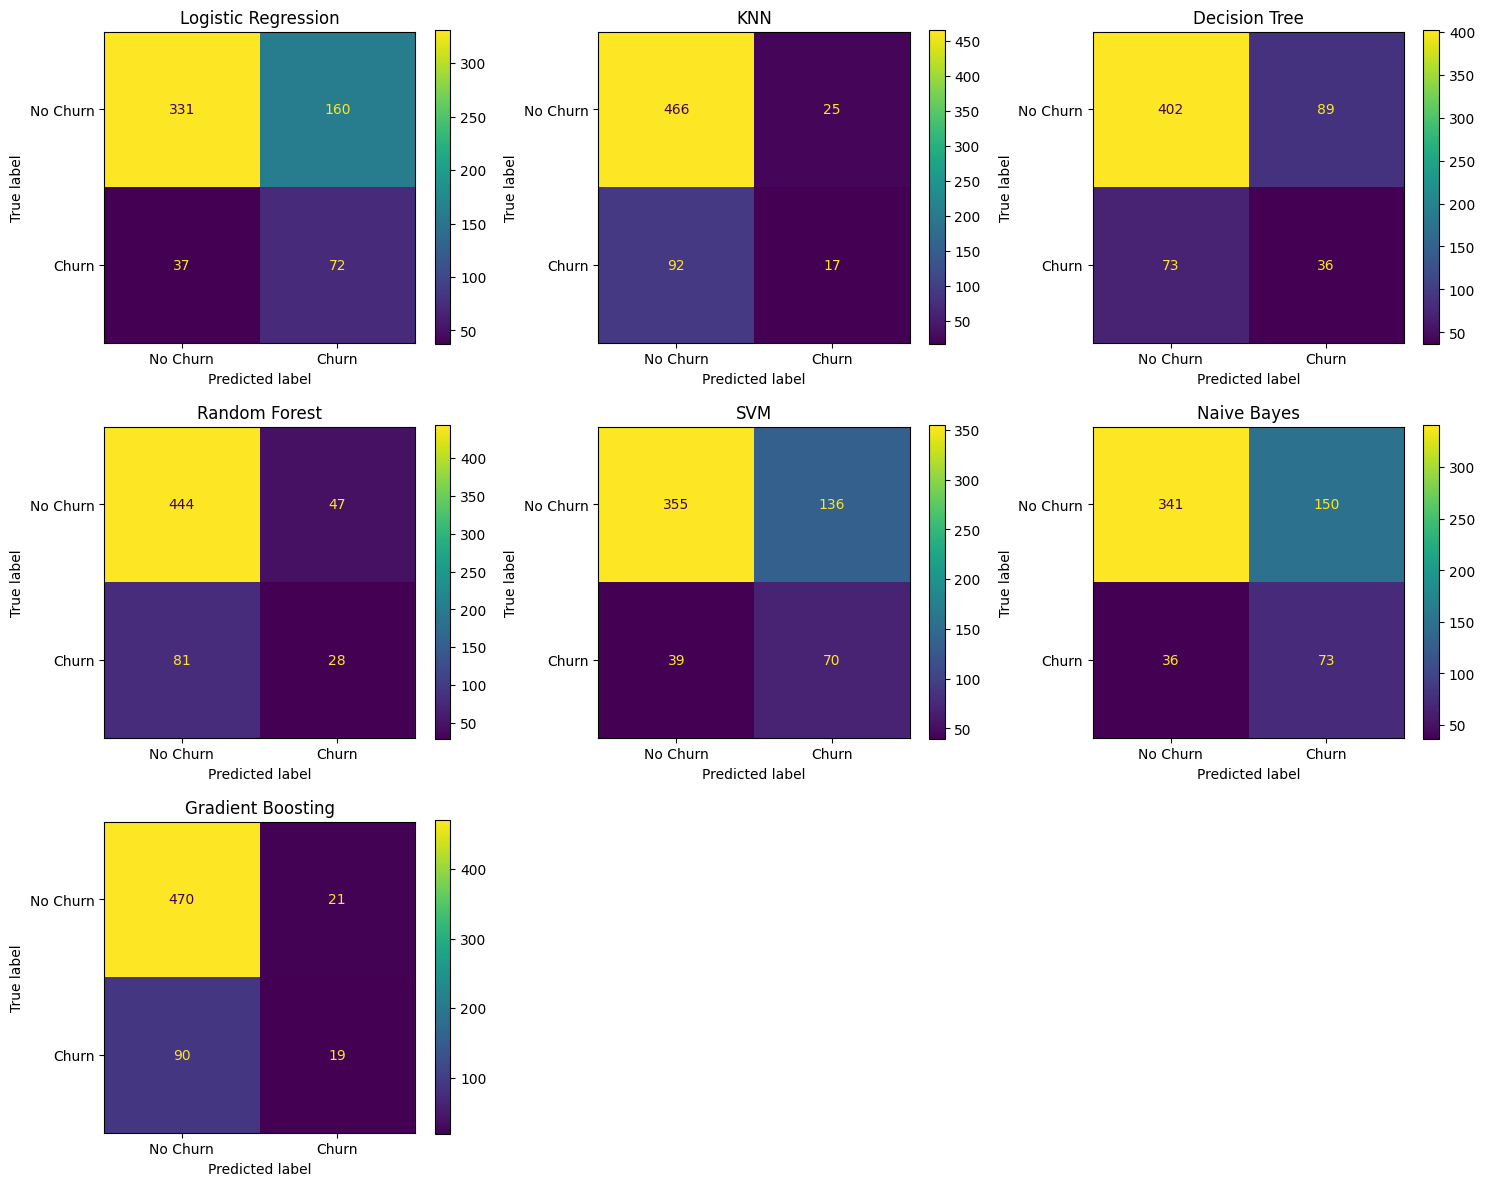

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, (name, model) in zip(axes.ravel(), classification_models.items()):

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(x_train_c, y_train_c)

    y_pred = pipeline.predict(x_test_c)

    cm = confusion_matrix(y_test_c, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot(ax=ax)
    ax.set_title(name)

for ax in axes.ravel()[len(classification_models):]:
    ax.axis("off")

plt.tight_layout()

plt.savefig('../images/Confusion Matrix for all Models.png')
plt.show()

### ROC curve for all models

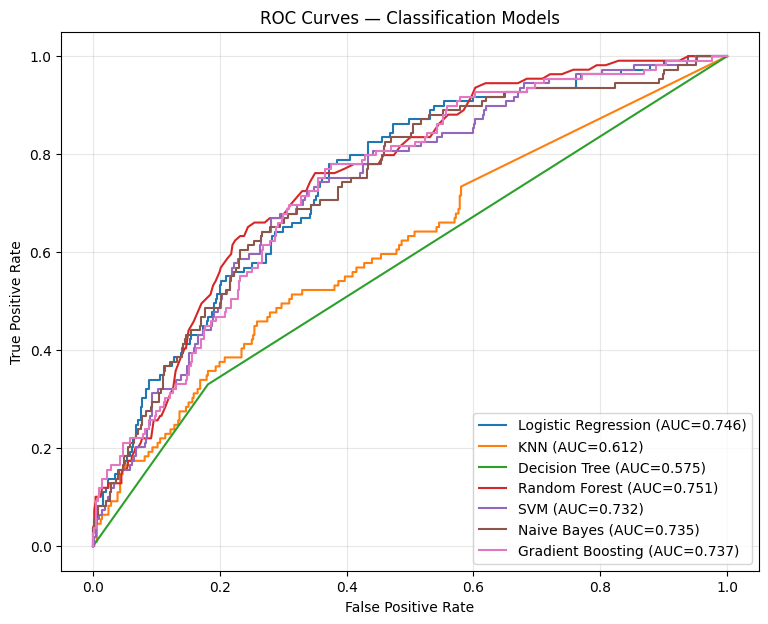

In [10]:
plt.figure(figsize=(9, 7))

for name, pipe in classification_pipelines.items():
    prob = pipe.predict_proba(x_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, prob)
    auc = roc_auc_score(y_test_c, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Part B: Revenue Regression

### Regression Models

In [11]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

regression_results = []
regression_pipelines = {}

for name, model in regression_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x_train_r, y_train_r)
    pred = pipe.predict(x_test_r)

    regression_pipelines[name] = pipe

    regression_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_r, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_r, pred)),
        "R2": r2_score(y_test_r, pred)
    })

regression_results_df = pd.DataFrame(regression_results).sort_values(
    "R2", ascending=False).reset_index(drop=True)

regression_results_df


,Model,MAE,RMSE,R2
0,Gradient Boosting Regressor,370.529531,468.032432,0.895445
1,Lasso,379.542112,476.230788,0.891750
2,Ridge,380.236481,477.135861,0.891338
3,Linear Regression,380.274272,477.181907,0.891317
4,Random Forest Regressor,392.970177,498.656565,0.881315
5,Decision Tree Regressor,512.525450,648.685333,0.799154
6,KNN Regressor,641.676657,810.185708,0.686698


#### Regression Model Evaluation

The regression models were evaluated using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score**.

#### Observations

- **Gradient Boosting Regressor** achieved the lowest MAE (370.53) and RMSE (468.03), along with the highest R² score (0.8954).
- **Lasso, Ridge, and Linear Regression** produced very similar results, with R² scores around 0.89.
- **Random Forest Regressor** achieved an R² score of 0.8813, performing reasonably well but below the boosting and linear models.
- **Decision Tree Regressor** performed worse than the ensemble and linear models, with an R² of 0.7992.
- **KNN Regressor** had the highest MAE and RMSE and the lowest R² score (0.6867).
- The results show that the models differ in their ability to predict **Future12MRevenueEGP** accurately.

### Conclusion

The evaluation shows that **Gradient Boosting Regressor** achieved the strongest performance across the reported metrics, with the lowest prediction errors and the highest R² score.

The model achieved an **R² of 0.8954**, meaning that approximately 89.5% of the variation in the target variable is explained by the model on the test set.

### Actual vs Predicted Revenue using Gradient Boosting Regressor

In [12]:
best_reg_name = regression_results_df.iloc[0]["Model"]
best_reg_pipe = regression_pipelines[best_reg_name]

best_reg_pred = best_reg_pipe.predict(x_test_r)

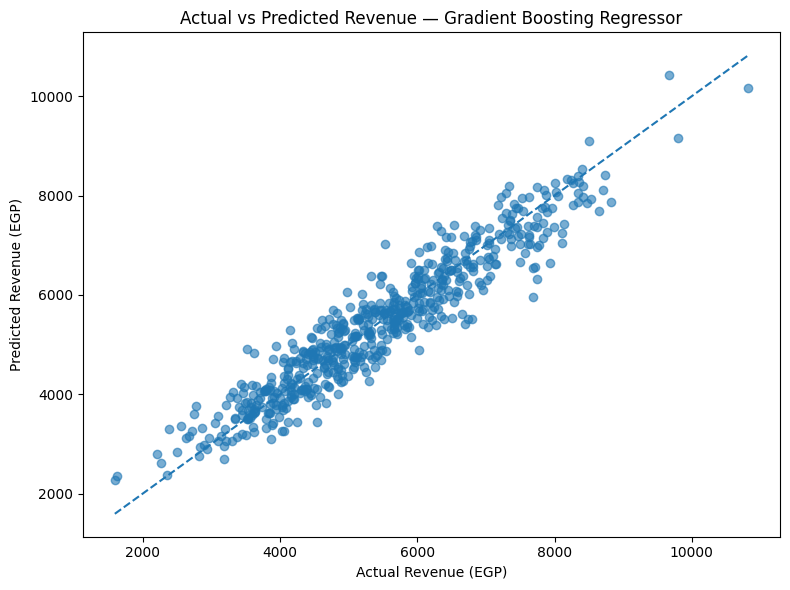

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_r, best_reg_pred, alpha=0.6)

min_val = min(y_test_r.min(), best_reg_pred.min())
max_val = max(y_test_r.max(), best_reg_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Revenue (EGP)")
plt.ylabel("Predicted Revenue (EGP)")
plt.title(f"Actual vs Predicted Revenue — {best_reg_name}")

plt.tight_layout()

plt.savefig('../images/Actual vs Predicted Revenue.png')
plt.show()
